# Стриминг (Streaming)

## Обзор (Review)

В модуле 2 мы рассмотрели несколько способов настройки состояния графа (graph state) и памяти (memory).

Мы создали чат-бота с внешней памятью, который может поддерживать длительные диалоги.

## Цели (Goals)

Этот модуль углубится в **human-in-the-loop** (человек в цикле), который расширяет возможности памяти (memory) и позволяет пользователям напрямую взаимодействовать с графами различными способами.

Чтобы подготовить почву для **human-in-the-loop**, мы сначала рассмотрим стриминг (streaming), который предоставляет несколько способов визуализации вывода графа (например, состояние узлов или токены чат-модели) в процессе выполнения.

=================================================================================================================

In [1]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.messages import HumanMessage
from langchain_gigachat import GigaChat

In [2]:
import os
api_key = os.getenv("GIGA_API_KEY")

In [3]:
llm = model = GigaChat(
    credentials = api_key,
    verify_ssl_certs=False,
    scope = 'GIGACHAT_API_CORP',
    temperature=0.0,
    profanity_check = False,
    model="GigaChat",
)

In [4]:
from IPython.display import Image, display

from langchain_core.messages import SystemMessage, HumanMessage, RemoveMessage
from langchain_core.runnables import RunnableConfig

from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import StateGraph, START, END
from langgraph.graph import MessagesState

In [5]:
# Состояние (State)
class State(MessagesState):
    summary: str

# Определяем логику вызова модели
def call_model(state: State, config: RunnableConfig):
    
    # Получаем саммаризацию (summary), если она существует
    summary = state.get("summary", "")

    # Если саммаризация (summary) есть, добавляем её
    if summary:
        
        # Добавляем саммаризацию (summary) в системное сообщение (SystemMessage)
        system_message = f"Саммаризация (summary) предыдущего разговора: {summary}"

        # Добавляем саммаризацию (summary) к новым сообщениям
        messages = [SystemMessage(content=system_message)] + state["messages"]
    
    else:
        messages = state["messages"]
    
    # Вызываем модель
    response = model.invoke(messages, config)
    return {"messages": response}

# Функция для создания саммаризации (summary) разговора
def summarize_conversation(state: State):
    
    # Сначала получаем существующую саммаризацию (summary), если она есть
    summary = state.get("summary", "")

    # Создаем промпт (prompt) для саммаризации (summarization)
    if summary:
        
        # Саммаризация (summary) уже существует
        summary_message = (
            f"Это саммаризация (summary) текущего разговора: {summary}\n\n"
            "Расширьте саммаризацию (summary), учитывая новые сообщения выше:"
        )
        
    else:
        summary_message = "Создайте саммаризацию (summary) разговора выше:"

    # Добавляем промпт (prompt) к истории сообщений
    messages = state["messages"] + [HumanMessage(content=summary_message)]
    response = model.invoke(messages)
    
    # Удаляем все сообщения, кроме двух последних
    delete_messages = [RemoveMessage(id=m.id) for m in state["messages"][:-2]]
    return {"summary": response.content, "messages": delete_messages}

# Определяем, нужно ли завершить разговор или создать саммаризацию (summary)
def should_continue(state: State):
    
    """Возвращает следующий узел (node) для выполнения."""
    
    messages = state["messages"]
    
    # Если сообщений больше шести, создаем саммаризацию (summary) разговора
    if len(messages) > 6:
        return "summarize_conversation"
    
    # Иначе завершаем выполнение
    return END

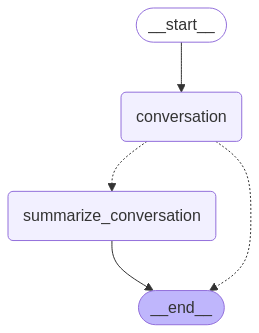

In [6]:
# Определяем новый граф
workflow = StateGraph(State)
workflow.add_node("conversation", call_model)
workflow.add_node(summarize_conversation)

# Устанавливаем точку входа (entrypoint) как "conversation"
workflow.add_edge(START, "conversation")
workflow.add_conditional_edges("conversation", should_continue)
workflow.add_edge("summarize_conversation", END)

# Компилируем граф
memory = MemorySaver()
graph = workflow.compile(checkpointer=memory)

# Отображаем граф
display(Image(graph.get_graph().draw_mermaid_png()))

### Стриминг полного состояния (Streaming full state)

Теперь давайте поговорим о способах [стриминга состояния графа](https://langchain-ai.github.io/langgraph/concepts/low_level/#streaming).

Методы `.stream` и `.astream` — это синхронные и асинхронные способы потоковой передачи результатов.

LangGraph поддерживает несколько [режимов стриминга](https://langchain-ai.github.io/langgraph/how-tos/stream-values/) для [состояния графа](https://langchain-ai.github.io/langgraph/how-tos/stream-values/):

* `values`: Передает полное состояние графа после вызова каждого узла.
* `updates`: Передает только обновления состояния графа после вызова каждого узла.

![values_vs_updates.png](https://cdn.prod.website-files.com/65b8cd72835ceeacd4449a53/66dbaf892d24625a201744e5_streaming1.png)

Давайте рассмотрим `stream_mode="updates"`.

Поскольку мы используем стриминг с `updates`, мы видим только обновления состояния после выполнения каждого узла графа.

Каждый `chunk` (чанк) — это словарь, где ключом является `node_name`, а значением — обновленное состояние.

In [7]:
# Создаем поток (thread)
config = {"configurable": {"thread_id": "1"}}

# Начинаем разговор
for chunk in graph.stream({"messages": [HumanMessage(content="Привет! Меня зовут Лэнс")]}, config, stream_mode="updates"):
    print(chunk)

{'conversation': {'messages': AIMessage(content='Привет, Лэнс! Приятно познакомиться. Чем могу быть полезен?', additional_kwargs={}, response_metadata={'token_usage': {'prompt_tokens': 21, 'completion_tokens': 19, 'total_tokens': 40, 'precached_prompt_tokens': 0}, 'model_name': 'GigaChat:1.0.26.20', 'x_headers': {'x-request-id': 'a7efd602-9132-474b-bc38-af3a0a04de66', 'x-session-id': 'd83f82ac-2219-47c4-8cb0-c34d804b4687', 'x-client-id': None}, 'finish_reason': 'stop'}, id='a7efd602-9132-474b-bc38-af3a0a04de66')}}


"Теперь давайте просто выведем обновление состояния."

In [8]:
# Start conversation
for chunk in graph.stream({"messages": [HumanMessage(content="Привет! Меня зовут Лэнс")]}, config, stream_mode="updates"):
    chunk['conversation']["messages"].pretty_print()

================================== Ai Message ==================================

Привет, Лэнс! Рад знакомству. Что интересного у тебя на уме?


____________________________________________________________________
Теперь мы можем увидеть `stream_mode="values"`.

Это **полное состояние (full state)** графа после вызова узла `conversation`.

In [9]:
# Start conversation, again
config = {"configurable": {"thread_id": "2"}}

# Start conversation
input_message = HumanMessage(content="Привет! Меня зовут Лэнс")
for event in graph.stream({"messages": [input_message]}, config, stream_mode="values"):
    for m in event['messages']:
        m.pretty_print()
    print("---"*25)

================================ Human Message =================================

Привет! Меня зовут Лэнс
---------------------------------------------------------------------------
================================ Human Message =================================

Привет! Меня зовут Лэнс
================================== Ai Message ==================================

Привет, Лэнс! Рад знакомству. Чем могу быть полезен?
---------------------------------------------------------------------------


==================================================================================

### Стриминг токенов (Streaming tokens)

Часто мы хотим стримить не только состояние графа.

В частности, при вызовах чат-модели обычно стримят токены по мере их генерации.

Мы можем сделать это [с помощью метода `.astream_events`](https://langchain-ai.github.io/langgraph/how-tos/streaming-from-final-node/#stream-outputs-from-the-final-node), который передает события по мере их возникновения внутри узлов!

Каждое событие — это словарь с несколькими ключами:

* `event`: Тип события, которое передается.
* `name`: Название события.
* `data`: Данные, связанные с событием.
* `metadata`: Содержит `langgraph_node`, узел, который передает событие.

Давайте посмотрим.

In [10]:
# Указываем конфигурацию для треда (thread)
config = {"configurable": {"thread_id": "3"}}

# Создаем входное сообщение
input_message = HumanMessage(content="Расскажи о команде NFL 49ers")

# Асинхронно обрабатываем события
async for event in graph.astream_events({"messages": [input_message]}, config, version="v2"):
    # Выводим информацию о событии
    print(f"Узел (Node): {event['metadata'].get('langgraph_node','')}. Тип (Type): {event['event']}. Название (Name): {event['name']}")
    break
    

Узел (Node): . Тип (Type): on_chain_start. Название (Name): LangGraph


-----------------------------------------------

Основной момент заключается в том, что токены от чат-моделей внутри вашего графа имеют тип `on_chat_model_stream`.

Мы можем использовать `event['metadata']['langgraph_node']`, чтобы выбрать узел, из которого будем стримить.

А также мы можем использовать `event['data']`, чтобы получить фактические данные для каждого события, которые в данном случае представляют собой `AIMessageChunk`.

In [11]:
node_to_stream = 'conversation'
config = {"configurable": {"thread_id": "4"}}
input_message = HumanMessage(content="Расскажи о команде NFL 49ers")
async for event in graph.astream_events({"messages": [input_message]}, config, version="v2"):
    # Get chat model tokens from a particular node 
    if event["event"] == "on_chat_model_stream" and event['metadata'].get('langgraph_node','') == node_to_stream:
        print(event["data"])
    break

In [12]:
# Указываем конфигурацию для треда (thread)
config = {"configurable": {"thread_id": "6"}}

# Создаем входное сообщение
input_message = HumanMessage(content="Расскажи о команде NFL 49ers")

# Асинхронно обрабатываем события
async for event in graph.astream_events({"messages": [input_message]}, config, version="v2"):
    # Получаем токены чат-модели из конкретного узла
    if event["event"] == "on_chat_model_stream" and event['metadata'].get('langgraph_node','') == node_to_stream:
        data = event["data"]
        print(data["chunk"].content, end="")

**Команда NFL San Francisco 49ers** (Сан-Франциско Форти Найнерс) – это профессиональная футбольная команда, базирующаяся в Сан-Франциско, штат Калифорния. Она играет в Национальной футбольной лиге (NFL) и является одной из самых успешных команд в истории американского футбола.

### История команды

1. **Основание и ранние годы**: Команда была основана в 1946 году как одна из команд-основателей АФЛ (Американской Футбольной Лиги), которая позже объединилась с NFL. В первые десятилетия своего существования команда не добивалась значительных успехов, но уже тогда начала формироваться её узнаваемая идентичность.
   
2. **Золотая эра**: Настоящий успех пришел к команде в 1980-х годах, когда под руководством тренера Билла Уолша и генерального менеджера Джона Йорка команда выиграла три Супербоула подряд (в 1981, 1984 и 1988 годах). Эти победы сделали команду культовой и установили высокие стандарты для будущих поколений игроков.

3. **Современные времена**: Несмотря на то что после золотой эр

==================================================================================================================



### Стриминг с использованием LangGraph API

**⚠️ ВНИМАНИЕ**

С момента съемки этих видео мы обновили Studio, чтобы её можно было запускать локально и открывать в браузере. Теперь это предпочтительный способ запуска Studio (вместо использования Desktop App, как показано в видео). См. документацию [здесь](https://langchain-ai.github.io/langgraph/concepts/langgraph_studio/#local-development-server) о локальном сервере разработки и [здесь](https://langchain-ai.github.io/langgraph/how-tos/local-studio/#run-the-development-server) о запуске Studio локально. Чтобы запустить локальный сервер разработки, выполните следующую команду в терминале в директории `/studio` этого модуля:

```
langgraph dev
```

Вы должны увидеть следующий вывод:
```
- 🚀 API: http://127.0.0.1:2024
- 🎨 Studio UI: https://smith.langchain.com/studio/?baseUrl=http://127.0.0.1:2024
- 📚 API Docs: http://127.0.0.1:2024/docs
```

Откройте браузер и перейдите по адресу Studio UI: `https://smith.langchain.com/studio/?baseUrl=http://127.0.0.1:2024`.

LangGraph API [поддерживает редактирование состояния графа](https://langchain-ai.github.io/langgraph/cloud/how-tos/human_in_the_loop_edit_state/#initial-invocation).




In [13]:
from langgraph_sdk import get_client

# This is the URL of the local development server
URL = "http://127.0.0.1:2024"
client = get_client(url=URL)

# Search all hosted graphs
assistants = await client.assistants.search()

In [14]:
# Создаем новый тред (thread)
thread = await client.threads.create()

# Создаем входное сообщение
input_message = HumanMessage(content="Умножь 2 и 3")

# Асинхронно стримим результаты
async for event in client.runs.stream(thread["thread_id"], 
                                      assistant_id="agent", 
                                      input={"messages": [input_message]}, 
                                      stream_mode="values"):
    print(event)

StreamPart(event='metadata', data={'run_id': '1f007e4e-21bf-65f9-86a7-333324a5c1e0', 'attempt': 1})
StreamPart(event='values', data={'messages': [{'content': 'Умножь 2 и 3', 'additional_kwargs': {}, 'response_metadata': {}, 'type': 'human', 'name': None, 'id': '4867d3e2-a305-4c2c-a83c-01faa3924246', 'example': False}]})
StreamPart(event='values', data={'messages': [{'content': 'Умножь 2 и 3', 'additional_kwargs': {}, 'response_metadata': {}, 'type': 'human', 'name': None, 'id': '4867d3e2-a305-4c2c-a83c-01faa3924246', 'example': False}, {'content': '', 'additional_kwargs': {'function_call': {'name': 'multiply', 'arguments': {'a': 2, 'b': 3}}, 'functions_state_id': 'c17f726d-5315-4d20-9847-131fd5ad8aa0'}, 'response_metadata': {'token_usage': {'prompt_tokens': 226, 'completion_tokens': 30, 'total_tokens': 256, 'precached_prompt_tokens': 0}, 'model_name': 'GigaChat:1.0.26.20', 'x_headers': {'x-request-id': 'bf797878-c3fb-44e6-8361-73837292426e', 'x-session-id': '8e808c17-c123-4844-9283-834

_______________________________________________________________________________________________
Стриминг возвращает объекты, содержащие:

* `event`: Тип события (Type)
* `data`: Состояние (State)

In [15]:
from langchain_core.messages import convert_to_messages

# Создаем новый тред (thread)
thread = await client.threads.create()

# Создаем входное сообщение
input_message = HumanMessage(content="Умножь 2 и 3")

# Асинхронно стримим результаты
async for event in client.runs.stream(thread["thread_id"], 
                                      assistant_id="agent", 
                                      input={"messages": [input_message]}, 
                                      stream_mode="values"):
    # Получаем сообщения из состояния (state)
    messages = event.data.get('messages', None)
    if messages:
        # Преобразуем и выводим последнее сообщение
        print(convert_to_messages(messages)[-1])
    # Разделитель для удобства чтения
    print('=' * 25)

content='Умножь 2 и 3' additional_kwargs={} response_metadata={} id='818a93ab-299c-484c-b9a3-8fa8a89c8aab'
content='' additional_kwargs={'invalid_tool_calls': [], 'usage_metadata': None, 'function_call': {'name': 'multiply', 'arguments': {'a': 2, 'b': 3}}, 'functions_state_id': 'adf57549-e063-4f1c-afd9-40637e239e4d'} response_metadata={'token_usage': {'prompt_tokens': 34, 'completion_tokens': 30, 'total_tokens': 64, 'precached_prompt_tokens': 192}, 'model_name': 'GigaChat:1.0.26.20', 'x_headers': {'x-request-id': 'd091a584-7664-4728-8f53-54a6fb92173f', 'x-session-id': '89ef2074-6e47-47bf-97e1-1284fdc2edb7', 'x-client-id': None}, 'finish_reason': 'function_call'} id='d091a584-7664-4728-8f53-54a6fb92173f' tool_calls=[{'name': 'multiply', 'args': {'a': 2, 'b': 3}, 'id': 'ff451216-3a57-4e3d-af48-7bdaae8fb7d6', 'type': 'tool_call'}]
content='6' name='multiply' id='a73dc72e-48a7-48bc-8f45-374033726be2' tool_call_id='ff451216-3a57-4e3d-af48-7bdaae8fb7d6'
content='Результат умножения 2 на 3 ра